In [2]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ---- 物理光谱网格：波长 380–700nm ----
wl_min, wl_max, wl_step = 380, 700, 5
wavelengths = np.arange(wl_min, wl_max + wl_step, wl_step)  # nm
n_wl = len(wavelengths)

# ---- 生成单色/窄带刺激的工具函数 ----
def make_narrow_spectrum(center_nm, width_nm=20.0, peak=1.0):
    """用高斯在波长轴上生成窄带光谱。"""
    sigma = width_nm / 2.355  # FWHM≈2.355σ
    spec = peak * np.exp(-0.5 * ((wavelengths - center_nm) / sigma) ** 2)
    return spec

# ---- 生成一个批次的刺激（多种波长 × 多个强度 × 重复）----
def make_batch_centers(n_centers=12, wl_lo=420, wl_hi=680):
    """在给定范围内等距或随机选取若干中心波长。"""
    return np.linspace(wl_lo, wl_hi, n_centers)

def make_stimuli_batch(centers, n_repeats=10, intensities=(0.4, 0.7, 1.0), noise_power=0.01):
    """返回列表，每个元素是一个 dict：{'wl_center':..., 'spectrum':...}"""
    batch = []
    for c in centers:
        for peak in intensities:
            for _ in range(n_repeats):
                spec = make_narrow_spectrum(c, width_nm=22.0, peak=peak)
                # 加少量噪声：符合“物理世界不确定”
                spec = np.clip(spec + rng.normal(0, noise_power, size=spec.shape), 0.0, None)
                batch.append({'wl_center': float(c), 'spectrum': spec})
    rng.shuffle(batch)
    return batch

# ---- 相位化采样（模拟微扫视/节律门控）----
def make_phase_gate(T=40, freq=1.0, phase=0.0):
    """
    生成长度为 T 的节律门函数（0~1），例如 sin^2 波。
    freq: 每 T 步里有 freq 个周期；phase: 相位偏移
    """
    t = np.arange(T)
    gate = np.sin(2 * np.pi * (freq * t / T) + phase) ** 2
    # 归一化到 [0.1, 1.0]，提高兼容性：用 max-min 替代 ptp()
    gmin, gmax = gate.min(), gate.max()
    gate = 0.1 + 0.9 * (gate - gmin) / (gmax - gmin + 1e-9)
    return gate

# ---- 生成一个演示批次 ----
centers = make_batch_centers(n_centers=10, wl_lo=420, wl_hi=680)
stim_batch = make_stimuli_batch(centers, n_repeats=6, intensities=(0.5, 0.8), noise_power=0.02)
phase_gate = make_phase_gate(T=40, freq=1.0, phase=0.0)

print(f"光谱维度: {n_wl}, 刺激数量: {len(stim_batch)}, 相位门长度: {len(phase_gate)}")

光谱维度: 65, 刺激数量: 120, 相位门长度: 40


In [3]:
# ---- 受体族群（略有差别的光谱敏感曲线）----
def gaussian_sensitivity(center, width):
    sigma = width / 2.355
    return np.exp(-0.5 * ((wavelengths - center) / sigma) ** 2)

# 三个主族群（类 S/M/L），但每族若干“个体”稍有偏移（更接近“生物群体”）
S_center, M_center, L_center = 440, 530, 560  # nm（可调整）
width = 40.0

def make_receptor_bank(n_per_group=3, jitter=8.0):
    centers = []
    for base in [S_center, M_center, L_center]:
        centers.extend(base + rng.normal(0, jitter, size=n_per_group))
    sens = np.stack([gaussian_sensitivity(c, width) for c in centers], axis=0)
    # 归一化每个受体的峰值到 1
    sens = sens / (sens.max(axis=1, keepdims=True) + 1e-9)
    return sens, np.array(centers)

receptor_sens, receptor_centers = make_receptor_bank(n_per_group=4, jitter=10.0)
n_receptors = receptor_sens.shape[0]

# ---- 汇聚到“簇”（类 glomeruli）：把相近受体加权汇合成 3 个簇 ----
# 简单做法：预先知道分三簇（S/M/L），每簇 4 个
cluster_map = np.array([0]*4 + [1]*4 + [2]*4)  # 12 个受体 → 3 个簇
n_clusters = 3

def pool_to_clusters(receptor_acts):
    """[T, n_receptors] → [T, 3]，按 cluster_map 平均"""
    pooled = np.zeros((receptor_acts.shape[0], n_clusters))
    for k in range(n_clusters):
        idx = np.where(cluster_map == k)[0]
        pooled[:, k] = receptor_acts[:, idx].mean(axis=1)
    return pooled

# ---- 侧抑 + 相位门控的动力系统 ----
def run_dynamics(spectrum, T=40, alpha=0.25, inhib=0.35, gate=None):
    """
    spectrum: [n_wl]
    返回：time-series 字典，包括
      - 'receptor_acts': [T, n_receptors]
      - 'cluster_acts' : [T, 3]
      - 'mitral'       : [T, 3]   （类二尖瓣输出）
    """
    if gate is None:
        gate = np.ones(T)
    # 光谱 → 每受体的瞬时输入（点积）
    base_in = receptor_sens @ spectrum  # [n_receptors]
    # 归一化，保证不同光强可比（仍保留幅度差异）
    base_in = base_in / (base_in.max() + 1e-9)
    # 时间推进（相位门调制“获得感”）
    receptor_acts = []
    for t in range(T):
        receptor_acts.append(base_in * gate[t])
    receptor_acts = np.stack(receptor_acts, axis=0)  # [T, n_receptors]

    # 汇聚成簇
    cluster_acts = pool_to_clusters(receptor_acts)   # [T, 3]

    # 侧抑网络（简单的连续动力学离散化）
    # m_{t+1} = (1-alpha)*m_t + alpha * relu( W_in * c_t - L * m_t )
    W_in = np.eye(3)  # 输入到“二尖瓣”的直连（可扩展为非对角）
    L = inhib * (np.ones((3,3)) - np.eye(3))  # 仅用 off-diagonal 实现侧抑
    m = np.zeros(3)
    mitral_series = []
    for t in range(T):
        drive = W_in @ cluster_acts[t]
        lateral = L @ m
        m = (1 - alpha) * m + alpha * np.maximum(0.0, drive - lateral)
        mitral_series.append(m.copy())
    mitral_series = np.stack(mitral_series, axis=0)

    return {
        'receptor_acts': receptor_acts,
        'cluster_acts' : cluster_acts,
        'mitral'       : mitral_series,
    }

# ---- 对一个样本试跑，检查维度 ----
demo = run_dynamics(stim_batch[0]['spectrum'], T=len(phase_gate), alpha=0.3, inhib=0.4, gate=phase_gate)
for k, v in demo.items():
    print(k, v.shape)

receptor_acts (40, 12)
cluster_acts (40, 3)
mitral (40, 3)


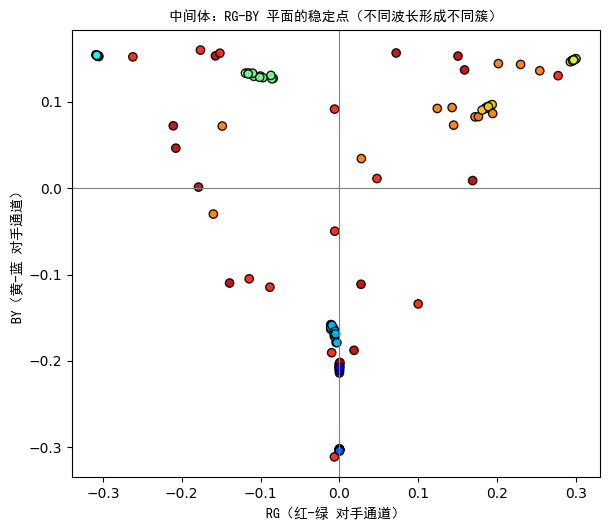

二元门控：BW（黑白/无彩）比例 = 0.02，COLOR（彩色）比例 = 0.98


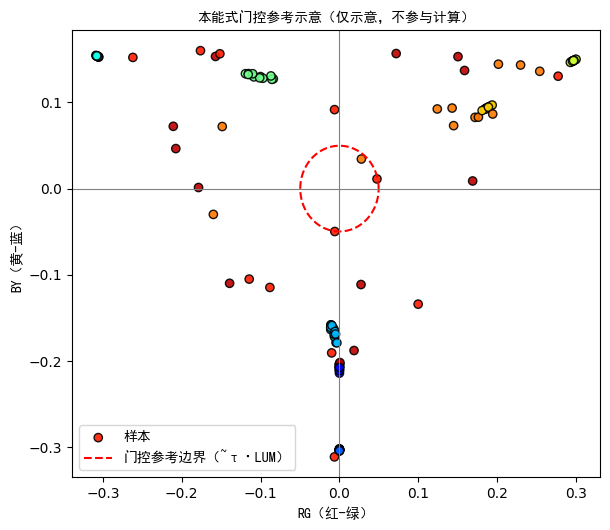

In [4]:
# ---- 中间体：对手通道（RG, BY）与亮度（LUM）----
def opponent_channels(mitral_series):
    """
    输入：[T, 3]，顺序假设为 [S, M, L] 簇
    输出：dict，含 RG, BY, LUM 的时间序列与末端值
    """
    S, M, L = mitral_series[:,0], mitral_series[:,1], mitral_series[:,2]
    RG  = L - M
    BY  = 0.5*(L + M) - S
    LUM = L + M + S
    return {
        'RG': RG, 'BY': BY, 'LUM': LUM,
        'RG_last': RG[-1], 'BY_last': BY[-1], 'LUM_last': LUM[-1]
    }

# ---- 本能式二元门控（黑白/彩色）----
def instinct_gate(RG_last, BY_last, LUM_last, tau=0.18):
    """
    chroma = sqrt(RG^2 + BY^2)
    若 chroma < tau * (LUM + eps) → 判为“黑白/无彩”（无需更多计算）
    否则 → 判为“彩色”（允许更精细）
    """
    chroma = np.sqrt(RG_last**2 + BY_last**2)
    eps = 1e-6
    return ('BW' if chroma < tau * (LUM_last + eps) else 'COLOR'), chroma

# ---- 跑完整个批次，收集中间体与门控输出 ----
def run_batch_and_collect(batch, T=40, alpha=0.3, inhib=0.4, gate=None, tau=0.18):
    records = []
    for item in batch:
        out = run_dynamics(item['spectrum'], T=T, alpha=alpha, inhib=inhib, gate=gate)
        opp = opponent_channels(out['mitral'])
        decision, chroma = instinct_gate(opp['RG_last'], opp['BY_last'], opp['LUM_last'], tau=tau)
        records.append({
            'wl_center': item['wl_center'],
            'RG_last': opp['RG_last'],
            'BY_last': opp['BY_last'],
            'LUM_last': opp['LUM_last'],
            'decision': decision,
            'chroma': chroma
        })
    return records

records = run_batch_and_collect(stim_batch, T=len(phase_gate), alpha=0.3, inhib=0.4, gate=phase_gate, tau=0.18)

# ---- 可视化 1：RG-BY 平面上的“中间体簇”，颜色仅用于人眼对照（计算未用标签）----
wl_list = np.array([r['wl_center'] for r in records])
RG_last = np.array([r['RG_last'] for r in records])
BY_last = np.array([r['BY_last'] for r in records])
decisions = np.array([r['decision'] for r in records])

# 把波长映射成可视化色彩（仅为读图方便）
def wl_to_rgb_nm(nm):
    nm = np.clip(nm, 380, 700)
    # 简化的可视化映射（非物理精准）
    t = (nm - 380) / 320.0
    return (np.clip(1.5 - 4*abs(t-0.75), 0, 1), np.clip(1.5 - 4*abs(t-0.5), 0, 1), np.clip(1.5 - 4*abs(t-0.25), 0, 1))

colors = np.array([wl_to_rgb_nm(nm) for nm in wl_list])

plt.figure(figsize=(6.2, 5.4))
plt.scatter(RG_last, BY_last, c=colors, edgecolors='k', alpha=0.9)
plt.axhline(0, color='gray', lw=0.8); plt.axvline(0, color='gray', lw=0.8)
plt.xlabel('RG（红-绿 对手通道）', fontproperties='SimHei')
plt.ylabel('BY（黄-蓝 对手通道）', fontproperties='SimHei')
plt.title('中间体：RG-BY 平面的稳定点（不同波长形成不同簇）', fontproperties='SimHei')
plt.tight_layout()
plt.show()

# ---- 可视化 2：二元门控结果统计 ----
bw_ratio = (decisions == 'BW').mean()
print(f"二元门控：BW（黑白/无彩）比例 = {bw_ratio:.2f}，COLOR（彩色）比例 = {1-bw_ratio:.2f}")

# 可选：画一个“门控边界”的参考圆（以 LUM 的中位数估计）
LUM_mid = np.median([r['LUM_last'] for r in records])
tau = 0.18
theta = np.linspace(0, 2*np.pi, 256)
r = tau * LUM_mid
plt.figure(figsize=(6.2, 5.4))
plt.scatter(RG_last, BY_last, c=colors, edgecolors='k', alpha=0.9, label='样本')
plt.plot(r*np.cos(theta), r*np.sin(theta), 'r--', label='门控参考边界（~τ·LUM）')
plt.axhline(0, color='gray', lw=0.8); plt.axvline(0, color='gray', lw=0.8)
plt.legend(prop={'family':'SimHei'})
plt.xlabel('RG（红-绿）', fontproperties='SimHei'); plt.ylabel('BY（黄-蓝）', fontproperties='SimHei')
plt.title('本能式门控参考示意（仅示意，不参与计算）', fontproperties='SimHei')
plt.tight_layout()
plt.show()

In [5]:
import numpy as np

# ---- 二元决策层动力学 ----
def run_decision_competition(RG_series, BY_series, LUM_series,
                             alpha_dec=0.25, inhib_dec=0.60,
                             T=None, feedback_gain=0.15):
    """
    输入：
        RG_series, BY_series, LUM_series : 来自中间态的时间序列
        alpha_dec  : 决策层的时间常数
        inhib_dec  : BW 与 COLOR 的互相抑制强度
        feedback_gain : 决策对中间态的反向塑形强度

    输出：
        BW_series, COLOR_series : 二元竞争神经元的时间序列
        RG_fb, BY_fb            : 反向塑形后的 RG/BY
    """
    if T is None:
        T = len(RG_series)

    BW = 0.1   # 初值：弱激活
    COLOR = 0.1

    BW_series = []
    COLOR_series = []

    # 反向修改的 RG/BY
    RG_fb = RG_series.copy()
    BY_fb = BY_series.copy()

    for t in range(T):
        RG = RG_fb[t]
        BY = BY_fb[t]
        L  = LUM_series[t]

        # ---- 决策动力学 ----
        drive_bw = (+1.0 * L - 0.6 * RG - 0.6 * BY)
        drive_color = (+1.2 * RG + 1.2 * BY)

        BW = (1 - alpha_dec) * BW + alpha_dec * np.maximum(0, drive_bw - inhib_dec * COLOR)
        COLOR = (1 - alpha_dec) * COLOR + alpha_dec * np.maximum(0, drive_color - inhib_dec * BW)

        BW_series.append(BW)
        COLOR_series.append(COLOR)

        # ---- 反向塑形（关键）----
        # COLOR > BW → 增强 RG/BY（更“彩”）
        # BW > COLOR → 抑制 RG/BY（更“灰”）
        delta = COLOR - BW
        RG_fb[t] = RG + feedback_gain * delta
        BY_fb[t] = BY + feedback_gain * delta

    return np.array(BW_series), np.array(COLOR_series), RG_fb, BY_fb


# ---- 整合：对一条光谱样本跑「中间态 + 决策层」 ----
def run_full_pipeline(spectrum, T=40,
                      alpha=0.3, inhib=0.4,
                      alpha_dec=0.25, inhib_dec=0.60,
                      feedback_gain=0.15,
                      gate=None):
    """
    返回：
        RG轨迹, BY轨迹 (原始 + 反向塑形版)
        BW轨迹, COLOR轨迹
    """
    # 1) 原本的 Light Sommelier 动力学
    out = run_dynamics(spectrum, T=T, alpha=alpha, inhib=inhib, gate=gate)
    opp = opponent_channels(out['mitral'])

    RG = opp['RG']
    BY = opp['BY']
    LUM = opp['LUM']

    # 2) 二元竞争层 + 反向塑形
    BW, COLOR, RG_fb, BY_fb = run_decision_competition(
        RG, BY, LUM,
        alpha_dec=alpha_dec,
        inhib_dec=inhib_dec,
        feedback_gain=feedback_gain,
        T=T
    )

    return RG, BY, RG_fb, BY_fb, BW, COLOR

In [6]:
import matplotlib.pyplot as plt

def plot_full_trajectory(RG, BY, RG_fb, BY_fb, BW, COLOR, title="轨迹示意"):
    T = len(RG)
    t = np.arange(T)

    plt.figure(figsize=(12,5))

    # ---- 左图：RG-BY 平面的轨迹 ----
    plt.subplot(1,2,1)
    plt.plot(RG, BY, 'o--', alpha=0.4, label='原始中间态')
    plt.plot(RG_fb, BY_fb, 'o-', alpha=0.9, label='反向塑形后')
    plt.axhline(0, color='gray', lw=0.5); plt.axvline(0, color='gray', lw=0.5)
    plt.xlabel("RG"); plt.ylabel("BY")
    plt.legend()
    plt.title("RG–BY 轨迹\n（中间态沿决策方向被挤压）")

    # ---- 右图：二元竞争 ----
    plt.subplot(1,2,2)
    plt.plot(t, BW, label='BW neuron')
    plt.plot(t, COLOR, label='COLOR neuron')
    plt.xlabel("Time")
    plt.ylabel("Activation")
    plt.title("二元竞争神经元轨迹")
    plt.legend()

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

C:\Users\cheny\AppData\Local\Temp\ipykernel_27428\2182490748.py:28: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_27428\2182490748.py:28: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_27428\2182490748.py:28: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_27428\2182490748.py:28: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_27428\2182490748.py:28: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_27428\2182490748.py:28: UserWarning: Glyph 24577 (\

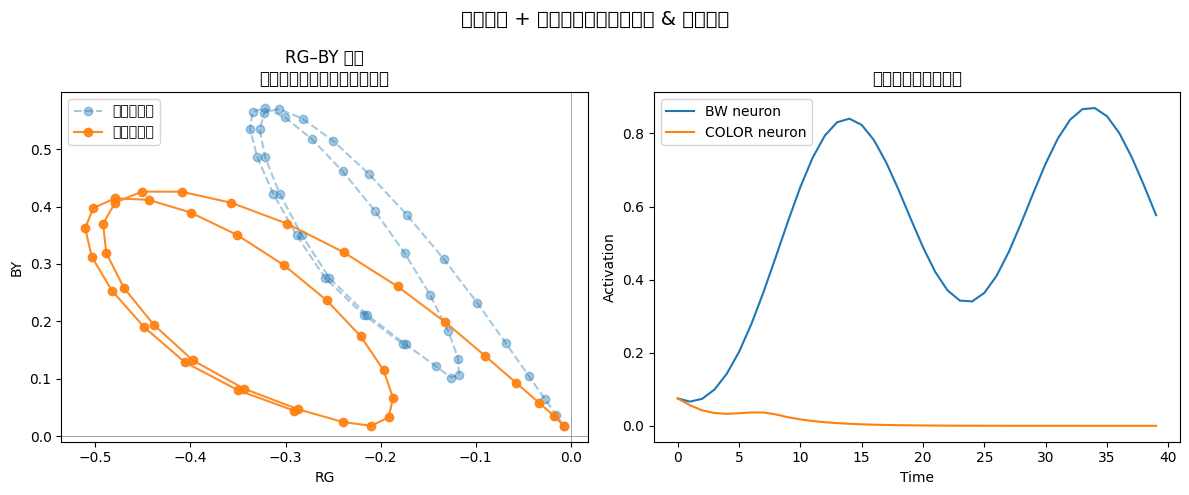

In [9]:
# ---- 试跑示例 ----

# 取一个样本光谱
sample = stim_batch[0]['spectrum']

# 跑完整管线（含反向塑形 + 二元竞争）
RG, BY, RG_fb, BY_fb, BW, COLOR = run_full_pipeline(
    sample,
    T=len(phase_gate),
    gate=phase_gate,
    feedback_gain=0.20   # 你可以调成 0.10 ~ 0.40 观察差异
)

# 画出轨迹（中间态轨迹 + 决策层轨迹）
plot_full_trajectory(
    RG, BY, RG_fb, BY_fb, BW, COLOR,
    title="二元竞争 + 反向塑形：中间态轨迹 & 决策轨迹"
)